<a href="https://colab.research.google.com/github/KuldeepIsharwal/Machine-Learning-Basics/blob/main/Polynomial_regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Polynomial regression :     

A form of regression that models the relationship between input features and the target as an nth-degree polynomial — extending linear regression to fit curved, non-linear relationships while still remaining a linear model in terms of its coefficients.


#Core Idea :

Linear regression fits a straight line. But real-world relationships are often curved. Polynomial regression fits a curve by adding powers of the original feature as new features — then running linear regression on those expanded features.
The key insight: the model is still linear in its coefficients (weights) — just non-linear in its features.


#Polynomial Regression (degree 3):
ŷ = w₁x + w₂x² + w₃x³ + b


-it is still called polynomial linear regression because the 'linear' term tells relationship between the y and the coeff. ( w ) .



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [3]:
x = 6 * np.random.rand(200, 1) - 3
y = 0.5 * x**2 + x + 2 + np.random.randn(200, 1)

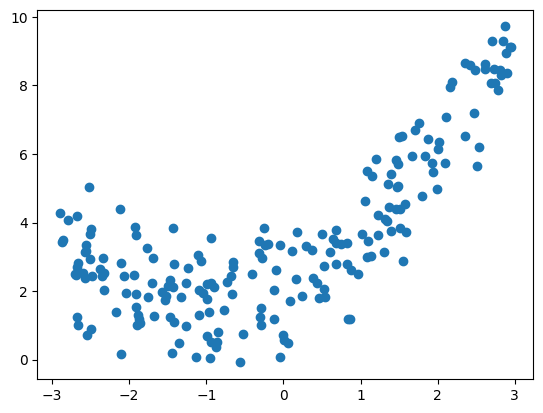

In [4]:
plt.scatter(x, y)
plt.show()

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [10]:
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.523388484452462

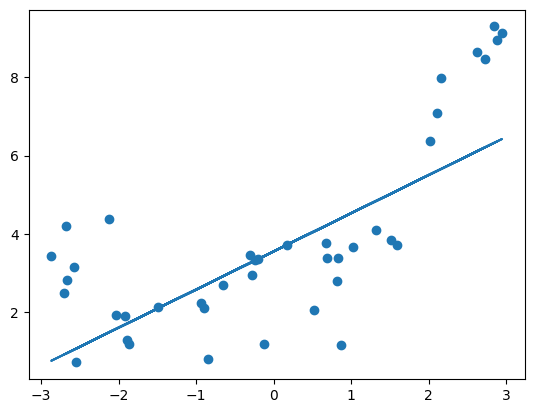

In [11]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)

#Now applying polynomial linear regression

In [42]:
poly = PolynomialFeatures(degree=3)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)


In [43]:
lr = LinearRegression()
lr.fit(x_train_poly,y_train)

LinearRegression()

In [44]:
y_pred_poly = lr.predict(x_test_poly)
r2_score(y_test,y_pred_poly)

0.8427450731190329

In [45]:
lr.coef_

array([[ 0.        ,  1.06191895,  0.48882441, -0.01368876]])

In [46]:
lr.intercept_

array([2.14717918])

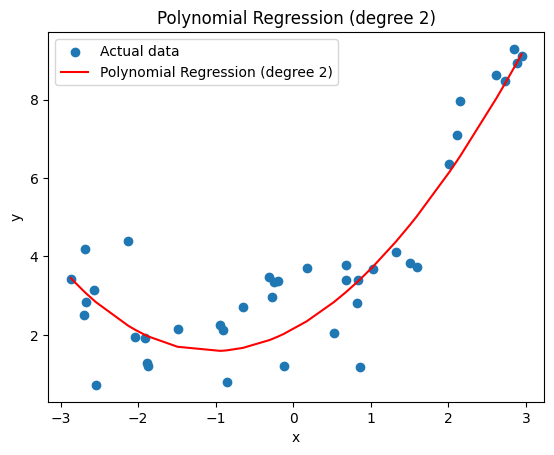

In [47]:
plt.scatter(x_test, y_test, label='Actual data')

# Sort x_test and y_pred_poly for a smooth plot
sorted_indices = np.argsort(x_test.flatten())
x_test_sorted = x_test[sorted_indices]
y_pred_poly_sorted = y_pred_poly[sorted_indices]

plt.plot(x_test_sorted, y_pred_poly_sorted, color='red', label='Polynomial Regression (degree 2)')
plt.title('Polynomial Regression (degree 2)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()